# 25 — What do all eleven models get wrong, and is it a chemistry problem?

**Read-only diagnostic. No training, no Chemprop, no torch, no submission, no model
change recommended. No external corpus retrieved, downloaded, or constructed here.**

## Motivation

Notebook 24 found this project's 11-config pool has raw-prediction correlations of
0.47-0.76 but *error* correlations of 0.79-0.91 (up to 0.97). The eleven models look
diverse in output and are not diverse in failure — they get the same compounds
wrong. That is the leading explanation for why ensembling has lost twice on the real
board (NB10 and NB12 both macro 0.8299 against the plain single model's 0.7138):
averaging cancels independent noise, not shared ignorance. It also reframes notebook
18's charge-augmented screen, whose 0.984-0.990 error correlation against its own
baseline was read at the time as "the feature did not reach the output" — the more
likely reading, given notebook 24, is that high error correlation is simply a
property of this pool.

The planned next step is a retrieved corpus of unlabelled near-neighbours of the
blind set, used to pretrain the encoder — expensive, and only worth building if the
compounds this project actually fails on are the kind of compounds such a corpus
would contain. **This notebook tests that premise cheaply, before the build.** It
characterises the compounds every model gets wrong (and, separately, the compounds
the models disagree about) and asks whether that population is structurally distant
from training (a corpus could plausibly help) or structurally ordinary (a corpus
would be aimed at the wrong problem). This is a diagnostic — it does not decide
anything and does not propose a model change.

## Scope boundaries (repeated here so they're visible in the executed notebook)
- No training, no Chemprop, no torch, no model of any kind is fit here.
- Read-only on `outputs/11_caruana_prep/`, `outputs/17_protonation_charge_check/`,
  `outputs/05_cv_comparison/`, `outputs/24_nonnegative_stacking/`, `data/`, `src/`,
  and every submission artifact.
- Protonation and fingerprint logic are reused from existing outputs/modules, never
  recomputed from scratch.
- ST-RAE and its error function are used only via the vendored evaluator, never
  reimplemented as a metric (see Part 1.4's explicit note on the one narrow
  exception this requires).
- No submission built, validated, or sent. No external corpus retrieved.


In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))

import importlib.metadata
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import fisher_exact, mannwhitneyu
from statsmodels.stats.multitest import multipletests

from src.features import (
    bemis_murcko_scaffold,
    ecfp4_fingerprints,
    nearest_neighbor_similarity,
)
from src.vendor.openadmet_eval.custom_scoring_functions import _resolve_bounds

print(f"python: {sys.version.split()[0]}")
for pkg in ["numpy", "pandas", "scipy", "seaborn", "matplotlib", "statsmodels", "rdkit"]:
    try:
        print(f"{pkg}: {importlib.metadata.version(pkg)}")
    except importlib.metadata.PackageNotFoundError:
        pass

ISOFORMS = ["CYP1A2", "CYP2C9", "CYP2D6", "CYP3A4"]
PIC50_COL = {iso: f"{iso}_pIC50_direct_inhibition" for iso in ISOFORMS}
N_REPEATS = 5
ALPHA = 0.05
HARD_QUANTILE = 0.90   # worst decile
EASY_QUANTILE = 0.10   # best decile
SCAFFOLD_MIN_MEMBERS = 5  # "more than a handful" (notebook 02's own phrase), stated explicitly here

OUT11PREP = REPO_ROOT / "outputs" / "11_caruana_prep"
OUT17 = REPO_ROOT / "outputs" / "17_protonation_charge_check"
OUT = REPO_ROOT / "outputs" / "25_hard_compound_analysis"
FIG_OUT = OUT / "figures"
FIG_OUT.mkdir(parents=True, exist_ok=True)

CURATED_PATH = REPO_ROOT / "data" / "processed" / "train_inhibition_curated.csv"
curated = pd.read_csv(CURATED_PATH)
print(f"\ncurated: {curated.shape}")

charge_logp = pd.read_csv(OUT17 / "charge_logp_features.csv")
print(f"charge_logp_features: {charge_logp.shape}, split values: {charge_logp['split'].value_counts().to_dict()}")


python: 3.11.13
numpy: 1.26.4
pandas: 2.3.3
scipy: 1.17.1
seaborn: 0.13.2
matplotlib: 3.11.1
statsmodels: 0.14.6
rdkit: 2026.3.3

curated: (4905, 20)
charge_logp_features: (5655, 7), split values: {'train': 4905, 'test': 750}


## Part 0 — Assemble the error matrix

`outputs/11_caruana_prep/oof_long_{iso}.csv` carries pooled 25-fold out-of-fold
predictions for the eleven real configs, plus `y_true`, `conf_low`, `conf_high`,
`inchikey`, `Molecule_Name`, `repeat` and `fold`. Read-only — loaded and inspected
below, never modified.


In [2]:
oof_tables = {}
CONFIG_COLS = None
for iso in ISOFORMS:
    df = pd.read_csv(OUT11PREP / f"oof_long_{iso}.csv")
    oof_tables[iso] = df
    cfg_cols = [c for c in df.columns
                if c not in ("repeat", "fold", "inchikey", "Molecule_Name", "y_true", "conf_low", "conf_high")]
    if CONFIG_COLS is None:
        CONFIG_COLS = cfg_cols
    else:
        assert cfg_cols == CONFIG_COLS, f"{iso}: config columns differ from {ISOFORMS[0]}"

    n_null = df[cfg_cols + ["y_true", "conf_low", "conf_high"]].isnull().any(axis=1).sum()
    n_compounds = df["inchikey"].nunique()
    rows_per_compound = df.groupby("inchikey").size()

    # y_true/conf_low/conf_high are compound properties, not prediction-dependent -- confirm
    # they are exactly constant across a compound's 5 repeat rows before averaging anything.
    const_check = df.groupby("inchikey")[["y_true", "conf_low", "conf_high"]].nunique().max().max()

    print(f"{iso}: {df.shape[0]} rows, {n_compounds} compounds, {len(cfg_cols)} config columns, "
          f"{n_null} rows with any null, rows/compound range [{rows_per_compound.min()}, {rows_per_compound.max()}], "
          f"max nunique(y_true/conf_low/conf_high) per compound = {const_check}")

    assert n_null == 0, f"{iso}: nulls found -- stopping rather than silently dropping, per task instructions"
    assert (rows_per_compound == N_REPEATS).all(), f"{iso}: not every compound has exactly {N_REPEATS} rows"
    assert const_check == 1, f"{iso}: y_true/conf_low/conf_high vary within a compound -- averaging assumption violated"

print(f"\nconfig columns ({len(CONFIG_COLS)}): {CONFIG_COLS}")
print("\nNo nulls in any isoform table; every compound has exactly 5 repeat rows; y_true/conf_low/conf_high "
      "confirmed constant per compound -- no null-handling policy needed, and the repeat-averaging step below "
      "is safe to apply uniformly.")


CYP1A2: 7060 rows, 1412 compounds, 11 config columns, 0 rows with any null, rows/compound range [5, 5], max nunique(y_true/conf_low/conf_high) per compound = 1
CYP2C9: 6425 rows, 1285 compounds, 11 config columns, 0 rows with any null, rows/compound range [5, 5], max nunique(y_true/conf_low/conf_high) per compound = 1
CYP2D6: 7465 rows, 1493 compounds, 11 config columns, 0 rows with any null, rows/compound range [5, 5], max nunique(y_true/conf_low/conf_high) per compound = 1
CYP3A4: 11675 rows, 2335 compounds, 11 config columns, 0 rows with any null, rows/compound range [5, 5], max nunique(y_true/conf_low/conf_high) per compound = 1

config columns (11): ['chemeleon__lightgbm', 'chemeleon__rf', 'chemeleon__xgboost', 'chemprop_chemeleoninit', 'chemprop_randominit', 'ecfp4_narrow__lightgbm', 'ecfp4_narrow__rf', 'ecfp4_narrow__xgboost', 'mordred_pca__lightgbm', 'mordred_pca__rf', 'mordred_pca__xgboost']

No nulls in any isoform table; every compound has exactly 5 repeat rows; y_true/conf_

### Repeat handling

Each compound appears in all 5 repeats (held out exactly once per repeat, under a
different fold partition each time — confirmed above: `oof_long` row count equals
`n_compounds x 5`). **Repeats are averaged per (compound, config): the reported
per-compound-per-config signed error is the mean of that config's 5 repeat-level
signed errors (`prediction - y_true`).** This separates compound-level difficulty
(does this compound get mispredicted consistently, across independently-trained
folds) from fold-to-fold training noise (does one particular fold's model happen to
miss it). The within-compound across-repeat standard deviation is reported alongside
so the size of that noise is visible rather than silently averaged away.


In [3]:
# Per (isoform, compound, config): mean signed error across the 5 repeats, and the
# within-compound across-repeat SD of that same signed error (the noise being averaged over).
compound_config_tables = {}
repeat_noise_summary_rows = []
for iso in ISOFORMS:
    df = oof_tables[iso]
    err = df[CONFIG_COLS].sub(df["y_true"], axis=0)  # signed error, prediction - y_true, per row
    err["inchikey"] = df["inchikey"].to_numpy()

    mean_err = err.groupby("inchikey")[CONFIG_COLS].mean()
    sd_err = err.groupby("inchikey")[CONFIG_COLS].std(ddof=1)  # across the 5 repeats, per config

    compound_config_tables[iso] = {"mean_signed_error": mean_err, "repeat_sd": sd_err}

    flat_sd = sd_err.to_numpy().ravel()
    repeat_noise_summary_rows.append({
        "isoform": iso, "n_compound_config_pairs": len(flat_sd),
        "repeat_sd_mean": flat_sd.mean(), "repeat_sd_median": np.median(flat_sd),
        "repeat_sd_p90": np.percentile(flat_sd, 90),
    })

repeat_noise_summary = pd.DataFrame(repeat_noise_summary_rows)
print("Within-compound, across-repeat SD of signed error (the fold-noise being averaged over),")
print("pooled across all 11 configs -- units: pIC50:")
print(repeat_noise_summary.round(4).to_string(index=False))


Within-compound, across-repeat SD of signed error (the fold-noise being averaged over),
pooled across all 11 configs -- units: pIC50:
isoform  n_compound_config_pairs  repeat_sd_mean  repeat_sd_median  repeat_sd_p90
 CYP1A2                    15532          0.2219            0.1925         0.3945
 CYP2C9                    14135          0.1724            0.1539         0.3017
 CYP2D6                    16423          0.1862            0.1637         0.3319
 CYP3A4                    25685          0.2254            0.1991         0.4020


## Part 1 — Define "hard" before looking at any chemistry

Frozen below and saved to `definitions.json` **before any chemical property is
computed** (no fingerprints, no RDKit descriptors, no scaffold has been touched yet
in this notebook), so the chemistry cannot be fitted to the answer.

1. **CONSENSUS-HARD**: worst decile (>= 90th percentile) by mean absolute error
   across all eleven configs (compound-level, repeat-averaged as above).
2. **CONSENSUS-EASY**: best decile (<= 10th percentile) by the same measure — the
   contrast set.
3. **DISAGREEMENT**: worst decile (>= 90th percentile) by standard deviation of
   signed error *across* the eleven configs. This decile convention is not specified
   in the task brief for this set specifically; it is adopted here for consistency
   with (1)/(2) and stated explicitly as this notebook's own choice, not the brief's.
   DISAGREEMENT is a **separate, complementary population** — reported on its own,
   never merged into CONSENSUS-HARD.
4. **Soft-threshold error**: computed per compound using the vendored evaluator's own
   per-point clipped-error formula (see the note in the next cell for exactly what is
   and is not reused), then averaged across configs the same way as plain absolute
   error. The consensus-hard/easy sets are compared under both definitions; if they
   differ materially, the soft-threshold version is carried forward as primary for
   Parts 2-4, since ST-RAE (not plain MAE) is what this project is actually scored on.

**Multiple-comparison correction (Part 2/3)**: Benjamini-Hochberg FDR correction
(`statsmodels.stats.multitest.multipletests`, `method="fdr_bh"`), matching this
project's own established convention (notebooks 05 and 24 both use BH for
many-comparison families) — applied once per isoform across every test performed for
that isoform, stated explicitly at the point of use.


In [4]:
# Per-compound soft-threshold error. The vendored rae_soft_threshold_absolute_error
# (src/vendor/openadmet_eval/custom_scoring_functions.py) returns a single AGGREGATE
# ratio (sum of clipped error / sum of a baseline's clipped error) -- it has no
# per-compound accessor, and calling it on a single compound directly is not valid:
# its baseline denominator collapses to exactly 0 for n=1 (mean_true == that
# compound's own y_true, so both clipped baseline terms are 0), which would divide by
# zero. The per-compound quantity used below is that function's own internal
# per-point numerator term, reproduced VERBATIM (not reimplemented) from its source:
# the two np.clip lines below are an exact copy of what
# rae_soft_threshold_absolute_error computes internally before summing, and
# _resolve_bounds is imported and called directly from the vendored module rather
# than re-derived. This is the ST-RAE numerator's own per-point error contribution,
# not a new metric -- and it is NOT divided by the (population-wide, per-isoform-
# constant) baseline denominator, so it does not change which compounds fall in the
# top/bottom decile relative to the fully-normalized metric; it is reported as an
# unnormalized quantity, labelled as such throughout.
def per_point_soft_threshold_error(y_true, y_pred, y_true_upper, y_true_lower):
    y_true_lower, y_true_upper = _resolve_bounds(np.asarray(y_true), y_true_upper, y_true_lower, None)
    above_upper = np.clip(np.asarray(y_pred) - y_true_upper, a_min=0, a_max=None)
    below_lower = np.clip(y_true_lower - np.asarray(y_pred), a_min=0, a_max=None)
    return above_upper + below_lower


compound_tables = {}
for iso in ISOFORMS:
    df = oof_tables[iso]
    mean_err = compound_config_tables[iso]["mean_signed_error"]  # (compound x config), repeat-averaged signed error

    # soft-threshold error computed row-wise (per repeat row) then repeat-averaged per config,
    # matching exactly how plain signed error was handled above (average over repeats first).
    soft_err_rows = pd.DataFrame(index=df.index, columns=CONFIG_COLS, dtype=float)
    for cfg in CONFIG_COLS:
        soft_err_rows[cfg] = per_point_soft_threshold_error(
            df["y_true"].to_numpy(), df[cfg].to_numpy(), df["conf_high"].to_numpy(), df["conf_low"].to_numpy()
        )
    soft_err_rows["inchikey"] = df["inchikey"].to_numpy()
    mean_soft_err = soft_err_rows.groupby("inchikey")[CONFIG_COLS].mean()

    compound_meta = df.drop_duplicates("inchikey").set_index("inchikey")[["y_true", "conf_low", "conf_high", "Molecule_Name"]]
    compound_meta = compound_meta.loc[mean_err.index]

    table = pd.DataFrame({
        "y_true": compound_meta["y_true"],
        "conf_low": compound_meta["conf_low"],
        "conf_high": compound_meta["conf_high"],
        "Molecule_Name": compound_meta["Molecule_Name"],
        "mean_abs_error": mean_err.abs().mean(axis=1),
        "across_config_sd_signed_error": mean_err.std(axis=1, ddof=1),
        "mean_soft_threshold_error": mean_soft_err.mean(axis=1),
        "mean_within_compound_repeat_sd": compound_config_tables[iso]["repeat_sd"].mean(axis=1),
    })
    compound_tables[iso] = table
    print(f"{iso}: compound-level table built, {table.shape[0]} compounds")

compound_tables[ISOFORMS[0]].head(3)


CYP1A2: compound-level table built, 1412 compounds
CYP2C9: compound-level table built, 1285 compounds
CYP2D6: compound-level table built, 1493 compounds
CYP3A4: compound-level table built, 2335 compounds


,y_true,conf_low,conf_high,Molecule_Name,mean_abs_error,across_config_sd_signed_error,mean_soft_threshold_error,mean_within_compound_repeat_sd
inchikey,,,,,,,,
AAFSKRHBWOQJCV-CVEARBPZSA-N,4.737715,4.512062,5.002109,OCNT-2309014,0.220963,0.262749,0.142565,0.270050
AAPHOXBNRLQGES-UHFFFAOYSA-N,5.117787,4.906878,5.287175,OCNT-2315503,0.101801,0.127653,0.042600,0.179357
ABUNSDMPQVALBH-UHFFFAOYSA-N,3.397317,1.939504,4.051556,OCNT-2314087,1.480106,0.206464,0.825867,0.197173


In [5]:
definitions = {
    "hard_quantile": HARD_QUANTILE, "easy_quantile": EASY_QUANTILE,
    "disagreement_quantile": HARD_QUANTILE,
    "disagreement_quantile_note": "not specified in the task brief for this set; adopted here "
        "for consistency with the consensus-hard/easy decile convention -- this notebook's own choice",
    "consensus_hard_measure": "mean absolute error across all 11 configs, repeat-averaged per config first",
    "consensus_easy_measure": "same measure as consensus-hard, best decile instead of worst",
    "disagreement_measure": "standard deviation of signed error across the 11 configs, repeat-averaged per config first",
    "soft_threshold_measure": "vendored per-point clipped-error formula (unnormalized), repeat-averaged per config, "
        "then averaged across the 11 configs",
    "multiple_comparison_correction": "Benjamini-Hochberg FDR (statsmodels fdr_bh), applied once per isoform "
        "across every test performed for that isoform",
    "scaffold_min_members_for_enrichment_check": SCAFFOLD_MIN_MEMBERS,
}
OUT.mkdir(parents=True, exist_ok=True)
with open(OUT / "definitions.json", "w") as f:
    json.dump(definitions, f, indent=2)
print(f"wrote {OUT / 'definitions.json'} -- frozen BEFORE any chemical property is computed below")
print(json.dumps(definitions, indent=2))


wrote /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/25_hard_compound_analysis/definitions.json -- frozen BEFORE any chemical property is computed below
{
  "hard_quantile": 0.9,
  "easy_quantile": 0.1,
  "disagreement_quantile": 0.9,
  "disagreement_quantile_note": "not specified in the task brief for this set; adopted here for consistency with the consensus-hard/easy decile convention -- this notebook's own choice",
  "consensus_hard_measure": "mean absolute error across all 11 configs, repeat-averaged per config first",
  "consensus_easy_measure": "same measure as consensus-hard, best decile instead of worst",
  "disagreement_measure": "standard deviation of signed error across the 11 configs, repeat-averaged per config first",
  "soft_threshold_measure": "vendored per-point clipped-error formula (unnormalized), repeat-averaged per config, then averaged across the 11 configs",
  "multiple_comparison_correction": "Benjamini-Hochberg FDR (statsmodels fdr_bh), applied once p

In [6]:
# label every compound: consensus_hard / consensus_easy / neither, on BOTH the plain-AE and
# soft-threshold measures, plus disagreement -- all decile cuts computed fresh per isoform.
for iso in ISOFORMS:
    t = compound_tables[iso]
    hard_cut_ae = t["mean_abs_error"].quantile(HARD_QUANTILE)
    easy_cut_ae = t["mean_abs_error"].quantile(EASY_QUANTILE)
    hard_cut_soft = t["mean_soft_threshold_error"].quantile(HARD_QUANTILE)
    easy_cut_soft = t["mean_soft_threshold_error"].quantile(EASY_QUANTILE)
    disagreement_cut = t["across_config_sd_signed_error"].quantile(HARD_QUANTILE)

    t["hard_ae"] = t["mean_abs_error"] >= hard_cut_ae
    t["easy_ae"] = t["mean_abs_error"] <= easy_cut_ae
    t["hard_soft"] = t["mean_soft_threshold_error"] >= hard_cut_soft
    t["easy_soft"] = t["mean_soft_threshold_error"] <= easy_cut_soft
    t["disagreement"] = t["across_config_sd_signed_error"] >= disagreement_cut

    print(f"{iso} (n={len(t)}): hard_ae={t['hard_ae'].sum()}, easy_ae={t['easy_ae'].sum()}, "
          f"hard_soft={t['hard_soft'].sum()}, easy_soft={t['easy_soft'].sum()}, disagreement={t['disagreement'].sum()}")


CYP1A2 (n=1412): hard_ae=142, easy_ae=142, hard_soft=142, easy_soft=142, disagreement=142
CYP2C9 (n=1285): hard_ae=129, easy_ae=129, hard_soft=129, easy_soft=129, disagreement=129
CYP2D6 (n=1493): hard_ae=150, easy_ae=150, hard_soft=150, easy_soft=150, disagreement=150
CYP3A4 (n=2335): hard_ae=234, easy_ae=234, hard_soft=234, easy_soft=234, disagreement=234


### Does the hard set change materially between plain-AE and soft-threshold error?

Compared via Jaccard overlap of the two "hard" decile sets (and separately the two
"easy" sets) per isoform. A Jaccard overlap below 0.8 is treated here as "material" —
an explicit, stated threshold (not given in the task brief), chosen because it means
more than 1 in 5 members of the smaller-effective-union set would change identity
under the alternative measure. Either way, **soft-threshold error is carried forward
as primary for Parts 2-4 below**, since ST-RAE is what this project is actually
scored on — the comparison below is reported for its own sake, not used to decide
whether to switch.


In [7]:
def jaccard(set_a, set_b):
    set_a, set_b = set(set_a), set(set_b)
    union = set_a | set_b
    return len(set_a & set_b) / len(union) if union else float("nan")

overlap_rows = []
for iso in ISOFORMS:
    t = compound_tables[iso]
    hard_jaccard = jaccard(t.index[t["hard_ae"]], t.index[t["hard_soft"]])
    easy_jaccard = jaccard(t.index[t["easy_ae"]], t.index[t["easy_soft"]])
    overlap_rows.append({
        "isoform": iso, "hard_jaccard_ae_vs_soft": hard_jaccard, "easy_jaccard_ae_vs_soft": easy_jaccard,
        "hard_material_difference": hard_jaccard < 0.8, "easy_material_difference": easy_jaccard < 0.8,
    })

overlap_table = pd.DataFrame(overlap_rows)
overlap_table.to_csv(OUT / "plain_vs_soft_threshold_overlap.csv", index=False)
print(overlap_table.round(3).to_string(index=False))


isoform  hard_jaccard_ae_vs_soft  easy_jaccard_ae_vs_soft  hard_material_difference  easy_material_difference
 CYP1A2                    0.479                    0.464                      True                      True
 CYP2C9                    0.395                    0.252                      True                      True
 CYP2D6                    0.442                    0.471                      True                      True
 CYP3A4                    0.307                    0.059                      True                      True


## Part 2 — What distinguishes the hard compounds?

Chemistry is computed for the first time in this notebook starting here — strictly
after `definitions.json` was written above. For each isoform: SMILES and physical
descriptors come from `data/processed/train_inhibition_curated.csv` (read-only,
canonical SMILES already present, not recomputed), net charge at pH 7.4 comes from
the **existing** `outputs/17_protonation_charge_check/charge_logp_features.csv`
column (not recomputed — no dimorphite-dl import anywhere in this notebook), and
fingerprints / nearest-neighbour similarity / Bemis-Murcko scaffolds all go through
`src/features.py`'s existing `ecfp4_fingerprints`, `nearest_neighbor_similarity` and
`bemis_murcko_scaffold` — reused exactly as notebook 02 used them, not reimplemented.


In [8]:
from src.features import rdkit_2d_descriptors  # reused, not reimplemented -- full RDKit 2D descriptor set

RDKIT_FIELDS = ["MolWt", "MolLogP", "TPSA", "HeavyAtomCount", "RingCount", "FractionCSP3"]

charge_train = charge_logp[charge_logp["split"] == "train"].set_index("inchikey")["net_charge_ph74"]
print(f"charge_train (existing column, reused not recomputed): {len(charge_train)} compounds")

chem_tables = {}
for iso in ISOFORMS:
    iso_pool = curated[curated[PIC50_COL[iso]].notna()].set_index("inchikey")
    assert iso_pool.index.isin(compound_tables[iso].index).all(), f"{iso}: oof compound missing from curated pool"
    assert set(iso_pool.index) == set(compound_tables[iso].index), f"{iso}: curated pool and oof compound set differ"

    smiles_list = iso_pool["canonical_smiles"].tolist()
    fps = ecfp4_fingerprints(smiles_list)
    n_fp_fail = sum(fp is None for fp in fps)
    assert n_fp_fail == 0, f"{iso}: {n_fp_fail} fingerprint failures -- stopping rather than silently dropping"

    loo_nn = nearest_neighbor_similarity(fps, fps, exclude_self_index=True)

    rdkit_rows = [rdkit_2d_descriptors(s) for s in smiles_list]
    rdkit_df = pd.DataFrame(rdkit_rows, index=iso_pool.index)[RDKIT_FIELDS]
    n_rdkit_null = rdkit_df.isnull().any(axis=1).sum()
    assert n_rdkit_null == 0, f"{iso}: {n_rdkit_null} RDKit descriptor failures -- stopping rather than silently dropping"

    scaffolds = pd.Series([bemis_murcko_scaffold(s) for s in smiles_list], index=iso_pool.index, name="scaffold")
    n_scaffold_fail = scaffolds.isnull().sum()
    assert n_scaffold_fail == 0, f"{iso}: {n_scaffold_fail} scaffold failures -- stopping rather than silently dropping"

    chem = rdkit_df.copy()
    chem["loo_nn_similarity"] = loo_nn
    chem["scaffold"] = scaffolds
    chem["net_charge_ph74"] = charge_train.reindex(iso_pool.index)
    n_charge_missing = chem["net_charge_ph74"].isnull().sum()
    assert n_charge_missing == 0, f"{iso}: {n_charge_missing} compounds missing net_charge_ph74 -- stopping"

    chem_tables[iso] = chem
    print(f"{iso}: chemistry computed for {len(chem)} compounds, 0 fingerprint/RDKit/scaffold/charge failures")

# join chemistry onto the compound tables (index-aligned, same compound set confirmed above)
for iso in ISOFORMS:
    compound_tables[iso] = compound_tables[iso].join(chem_tables[iso], how="left")
    assert compound_tables[iso].isnull().sum().sum() == 0, f"{iso}: nulls introduced by the join"

compound_tables[ISOFORMS[0]].head(3)


charge_train (existing column, reused not recomputed): 4905 compounds


CYP1A2: chemistry computed for 1412 compounds, 0 fingerprint/RDKit/scaffold/charge failures


CYP2C9: chemistry computed for 1285 compounds, 0 fingerprint/RDKit/scaffold/charge failures


CYP2D6: chemistry computed for 1493 compounds, 0 fingerprint/RDKit/scaffold/charge failures


CYP3A4: chemistry computed for 2335 compounds, 0 fingerprint/RDKit/scaffold/charge failures


,y_true,conf_low,conf_high,Molecule_Name,mean_abs_error,across_config_sd_signed_error,mean_soft_threshold_error,mean_within_compound_repeat_sd,hard_ae,easy_ae,...,disagreement,MolWt,MolLogP,TPSA,HeavyAtomCount,RingCount,FractionCSP3,loo_nn_similarity,scaffold,net_charge_ph74
inchikey,,,,,,,,,,,,,,,,,,,,,
AAFSKRHBWOQJCV-CVEARBPZSA-N,4.737715,4.512062,5.002109,OCNT-2309014,0.220963,0.262749,0.142565,0.270050,False,False,...,False,338.363,1.90970,84.47,25,4,0.263158,0.441176,O=C(N[C@@H]1CCCc2ccccc21)c1cccc2[nH]c(=O)oc12,0
AAPHOXBNRLQGES-UHFFFAOYSA-N,5.117787,4.906878,5.287175,OCNT-2315503,0.101801,0.127653,0.042600,0.179357,False,True,...,False,336.399,3.56600,87.63,25,4,0.277778,0.424658,O=C(Nc1ccc(Cn2cccn2)cc1)Nc1[nH]ncc1C1CCC1,-1
ABUNSDMPQVALBH-UHFFFAOYSA-N,3.397317,1.939504,4.051556,OCNT-2314087,1.480106,0.206464,0.825867,0.197173,False,False,...,False,426.480,3.83932,100.80,32,6,0.291667,0.447368,O=C1CC(c2nc(-c3cccc(-c4nnc[nH]4)c3)no2)CN1c1cc...,-1


### Reference figures, verified against their source notebooks before being quoted

- Notebook 02, cell 15's own markdown output: pooled (all-isoform) within-train
  leave-one-out NN Tanimoto median **0.450**; pooled test-to-train NN median
  **0.587** (Mann-Whitney p ~ 1.3e-225). Confirmed directly against that notebook's
  saved cell output before use here — these are pooled-across-isoform reference
  points, not a substitute for this notebook's own per-isoform LOO NN computation
  above, which uses a different (per-isoform-pool) population.
- Notebook 21, cell 6's own saved output: Spearman(interval width, pIC50) per
  isoform = CYP1A2 -0.885, CYP2C9 -0.899, CYP2D6 -0.558, CYP3A4 -0.928 — confirmed
  directly against that notebook's saved output, matching the task brief's quoted
  "-0.56 to -0.93" range exactly.


### Statistical comparison: CONSENSUS-HARD vs. CONSENSUS-EASY (soft-threshold definition)

Two independent groups of compounds (not repeated measures on the same fold
structure — a different comparison design from notebooks 05/24's paired CV-fold
tests), compared with the **Mann-Whitney U test**, matching this project's own
precedent for exactly this kind of two-independent-group similarity comparison
(notebook 02's own `test_to_train_nn` vs. `train_loo_nn` comparison used the
identical test). Effect size is the **rank-biserial correlation**
(`r = 1 - 2U/(n1*n2)`), reported alongside the median of each group so direction and
magnitude are both visible, not just significance. Ten continuous properties are
tested per isoform (NN similarity, CI width, pIC50, MolWt, MolLogP, TPSA,
HeavyAtomCount, RingCount, FractionCSP3, net charge), plus any qualifying scaffold
enrichment tests (below) — **all folded into one Benjamini-Hochberg family per
isoform**, per the correction stated in Part 1.


In [9]:
# interval width computed once, alongside the raw bounds
for iso in ISOFORMS:
    compound_tables[iso]["interval_width"] = compound_tables[iso]["conf_high"] - compound_tables[iso]["conf_low"]

CONTINUOUS_PROPERTIES = {
    "loo_nn_similarity": "similarity, unitless [0,1]",
    "interval_width": "credible-interval width, pIC50 units",
    "y_true": "pIC50",
    "MolWt": "g/mol",
    "MolLogP": "Crippen logP, unitless",
    "TPSA": "A^2",
    "HeavyAtomCount": "count",
    "RingCount": "count",
    "FractionCSP3": "unitless [0,1]",
    "net_charge_ph74": "formal charge, e",
}


def rank_biserial(hard_vals, easy_vals):
    n1, n2 = len(hard_vals), len(easy_vals)
    u_stat, p_val = mannwhitneyu(hard_vals, easy_vals, alternative="two-sided")
    r = 1 - (2 * u_stat) / (n1 * n2)
    return float(u_stat), float(p_val), float(r)


continuous_test_rows = []
for iso in ISOFORMS:
    t = compound_tables[iso]
    hard = t[t["hard_soft"]]
    easy = t[t["easy_soft"]]
    for prop, unit in CONTINUOUS_PROPERTIES.items():
        u_stat, p_val, r = rank_biserial(hard[prop].to_numpy(), easy[prop].to_numpy())
        continuous_test_rows.append({
            "isoform": iso, "property": prop, "unit": unit,
            "n_hard": len(hard), "n_easy": len(easy),
            "hard_median": hard[prop].median(), "easy_median": easy[prop].median(),
            "U": u_stat, "p_raw": p_val, "rank_biserial_r": r,
        })

continuous_tests = pd.DataFrame(continuous_test_rows)
print(f"{len(continuous_tests)} continuous tests computed ({len(CONTINUOUS_PROPERTIES)} properties x {len(ISOFORMS)} isoforms)")
continuous_tests.round(4)


40 continuous tests computed (10 properties x 4 isoforms)


,isoform,property,unit,n_hard,n_easy,hard_median,easy_median,U,p_raw,rank_biserial_r
0,CYP1A2,loo_nn_similarity,"similarity, unitless [0,1]",142,142,0.4014,0.3913,11031.0,0.1705,-0.0941
1,CYP1A2,interval_width,"credible-interval width, pIC50 units",142,142,0.2213,0.3835,7382.0,0.0001,0.2678
2,CYP1A2,y_true,pIC50,142,142,6.2423,4.9840,12878.0,0.0001,-0.2773
3,CYP1A2,MolWt,g/mol,142,142,333.8280,334.9150,10303.0,0.7500,-0.0219
4,CYP1A2,MolLogP,"Crippen logP, unitless",142,142,2.9400,3.2183,8215.0,0.0070,0.1852
5,CYP1A2,TPSA,A^2,142,142,67.0900,64.2800,11139.5,0.1267,-0.1049
6,CYP1A2,HeavyAtomCount,count,142,142,24.0000,24.0000,9617.5,0.4987,0.0461
7,CYP1A2,RingCount,count,142,142,3.0000,4.0000,7771.5,0.0003,0.2292
8,CYP1A2,FractionCSP3,"unitless [0,1]",142,142,0.3022,0.3125,9396.0,0.3217,0.0680
9,CYP1A2,net_charge_ph74,"formal charge, e",142,142,0.0000,0.0000,8579.0,0.0139,0.1491


### Scaffold enrichment

Notebook 02 found 96.4% of Bemis-Murcko scaffolds (over the full 4,905-compound
training set) are singletons — so scaffold families are not expected to explain
much. Checked here per isoform, fresh (isoform-specific pools are smaller than the
full training set, so this is not simply re-quoting notebook 02's number): for every
scaffold with at least `SCAFFOLD_MIN_MEMBERS` (5) compounds in that isoform's own
pool, a 2x2 Fisher's exact test (in-scaffold x in-consensus-hard) checks whether the
hard set is enriched for that scaffold specifically.


In [10]:
scaffold_test_rows = []
for iso in ISOFORMS:
    t = compound_tables[iso]
    scaffold_counts = t["scaffold"].value_counts()
    qualifying = scaffold_counts[scaffold_counts >= SCAFFOLD_MIN_MEMBERS].index.tolist()
    print(f"{iso}: {len(scaffold_counts)} distinct scaffolds, {len(qualifying)} with >= {SCAFFOLD_MIN_MEMBERS} members")

    for scaf in qualifying:
        in_scaffold = t["scaffold"] == scaf
        table_2x2 = [
            [int((in_scaffold & t["hard_soft"]).sum()), int((in_scaffold & ~t["hard_soft"]).sum())],
            [int((~in_scaffold & t["hard_soft"]).sum()), int((~in_scaffold & ~t["hard_soft"]).sum())],
        ]
        odds_ratio, p_val = fisher_exact(table_2x2)
        scaffold_test_rows.append({
            "isoform": iso, "scaffold": scaf, "n_in_scaffold": int(in_scaffold.sum()),
            "n_in_scaffold_and_hard": table_2x2[0][0], "odds_ratio": odds_ratio, "p_raw": p_val,
        })

scaffold_tests = pd.DataFrame(scaffold_test_rows)
if len(scaffold_tests) == 0:
    print("\nNo scaffold in any isoform reaches the >=5-member qualifying bar for a hard-set enrichment "
          "check -- consistent with notebook 02's own finding that this training set is heavily "
          "scaffold-fragmented, stated plainly rather than working around the empty result.")
else:
    print(f"\n{len(scaffold_tests)} scaffold enrichment tests computed across all isoforms")
    print(scaffold_tests.round(4).to_string(index=False))


CYP1A2: 1364 distinct scaffolds, 2 with >= 5 members
CYP2C9: 1255 distinct scaffolds, 1 with >= 5 members
CYP2D6: 1447 distinct scaffolds, 1 with >= 5 members
CYP3A4: 2096 distinct scaffolds, 16 with >= 5 members

20 scaffold enrichment tests computed across all isoforms
isoform                                      scaffold  n_in_scaffold  n_in_scaffold_and_hard  odds_ratio  p_raw
 CYP1A2                                      c1ccccc1             16                       0      0.0000 0.3941
 CYP1A2                                c1ccc2ncccc2c1              7                       2      3.6143 0.1508
 CYP2C9                                      c1ccccc1              7                       1      1.4974 0.5240
 CYP2D6                                      c1ccccc1             20                       2      0.9947 1.0000
 CYP3A4                    O=S(=O)(Nc1ccccc1)c1ccccc1             27                       2      0.7159 1.0000
 CYP3A4                                      c1ccccc1   

### One Benjamini-Hochberg family per isoform, continuous tests + scaffold tests together


In [11]:
all_tests = continuous_tests.copy()
all_tests["test_kind"] = "continuous"
if len(scaffold_tests) > 0:
    scaf_for_merge = scaffold_tests.rename(columns={"scaffold": "property"}).copy()
    # an empty-string scaffold is a real, valid Bemis-Murcko result (a ring-free/acyclic
    # compound has no scaffold) -- labelled explicitly here so it prints legibly and is not
    # mistaken for a missing value when this table is read back from disk.
    scaf_for_merge["property"] = scaf_for_merge["property"].replace("", "(acyclic / no ring)")
    scaf_for_merge["test_kind"] = "scaffold_enrichment"
    all_tests = pd.concat([all_tests, scaf_for_merge], ignore_index=True, sort=False)

all_tests["p_adj"] = np.nan
for iso in ISOFORMS:
    mask = all_tests["isoform"] == iso
    n_tests = mask.sum()
    _, p_adj, _, _ = multipletests(all_tests.loc[mask, "p_raw"].to_numpy(), method="fdr_bh")
    all_tests.loc[mask, "p_adj"] = p_adj
    print(f"{iso}: {n_tests} tests in the BH family, {int((p_adj < ALPHA).sum())} significant at BH-adjusted alpha={ALPHA}")

all_tests["significant"] = all_tests["p_adj"] < ALPHA
all_tests.to_csv(OUT / "hard_vs_easy_tests.csv", index=False)
print(f"\nwrote {OUT / 'hard_vs_easy_tests.csv'}")


CYP1A2: 12 tests in the BH family, 5 significant at BH-adjusted alpha=0.05
CYP2C9: 11 tests in the BH family, 6 significant at BH-adjusted alpha=0.05
CYP2D6: 11 tests in the BH family, 6 significant at BH-adjusted alpha=0.05
CYP3A4: 26 tests in the BH family, 9 significant at BH-adjusted alpha=0.05

wrote /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/25_hard_compound_analysis/hard_vs_easy_tests.csv


### Which properties separate hard from easy by a margin worth acting on

A margin "worth acting on" requires BOTH statistical significance (BH-adjusted
p < 0.05) AND a non-trivial effect size — `|rank_biserial_r| >= 0.3` for continuous
properties (a conventional "medium" threshold, stated explicitly since the brief does
not fix one) or, for scaffold enrichment, at least 3 hard-set members in the
enriched scaffold (so "enrichment" isn't being driven by 1-2 compounds). Properties
clearing significance alone, without a material effect size, are reported but not
treated as findings — this is the explicit alternative to "a long list of marginal
p-values reported as if each were a finding."


In [12]:
EFFECT_SIZE_THRESHOLD = 0.3

def worth_acting_on(row):
    if row["test_kind"] == "continuous":
        return bool(row["significant"] and abs(row["rank_biserial_r"]) >= EFFECT_SIZE_THRESHOLD)
    return bool(row["significant"] and row["n_in_scaffold_and_hard"] >= 3)

all_tests["worth_acting_on"] = all_tests.apply(worth_acting_on, axis=1)

for iso in ISOFORMS:
    sub = all_tests[all_tests["isoform"] == iso]
    material = sub[sub["worth_acting_on"]]
    sig_only = sub[sub["significant"] & ~sub["worth_acting_on"]]
    print(f"\n{iso}:")
    if len(material) == 0:
        print("  NOTHING clears both significance and the effect-size bar -- no property separates hard from easy "
              "by a margin worth acting on for this isoform.")
    else:
        cols = ["property", "test_kind", "hard_median", "easy_median", "rank_biserial_r", "p_adj"]
        print("  MATERIAL (significant AND |r|>=0.3, or scaffold with >=3 hard members):")
        print(material[[c for c in cols if c in material.columns]].round(4).to_string(index=False))
    if len(sig_only) > 0:
        print(f"  Significant but below the effect-size bar (NOT treated as findings): {sig_only['property'].tolist()}")



CYP1A2:
  NOTHING clears both significance and the effect-size bar -- no property separates hard from easy by a margin worth acting on for this isoform.
  Significant but below the effect-size bar (NOT treated as findings): ['interval_width', 'y_true', 'MolLogP', 'RingCount', 'net_charge_ph74']

CYP2C9:
  MATERIAL (significant AND |r|>=0.3, or scaffold with >=3 hard members):
       property  test_kind  hard_median  easy_median  rank_biserial_r  p_adj
 interval_width continuous       0.2343       0.7692           0.7018    0.0
         y_true continuous       5.7111       4.3815          -0.7149    0.0
        MolLogP continuous       2.9906       2.6081          -0.3206    0.0
   FractionCSP3 continuous       0.2941       0.4091           0.3979    0.0
net_charge_ph74 continuous       0.0000       1.0000           0.3182    0.0
  Significant but below the effect-size bar (NOT treated as findings): ['MolWt']

CYP2D6:
  MATERIAL (significant AND |r|>=0.3, or scaffold with >=3 hard memb

## Part 3 — Are the hard compounds the same across isoforms?

A compound-intrinsic difficulty (bad measurement, unusual chemistry) should transfer
across isoforms it is measured on; an isoform-specific difficulty (a particular
assay/target quirk) should not. For every pair of isoforms, restricted to compounds
with a non-null label on **both**, this checks whether `hard_soft` status on one
predicts `hard_soft` status on the other via a 2x2 contingency table, Fisher's exact
test, and the phi coefficient (equivalent to the Pearson correlation between the two
binary indicators) as effect size. The 6 isoform pairs are one BH family, separate
from Part 2's per-isoform families (a different comparison unit — pairs of isoforms,
not properties within one isoform).


In [13]:
from itertools import combinations

hard_status = pd.DataFrame({iso: compound_tables[iso]["hard_soft"] for iso in ISOFORMS})
print(f"hard_status table: {hard_status.shape} (NaN where a compound has no label on that isoform)")
print("compounds with a label on >=2 isoforms:", (hard_status.notna().sum(axis=1) >= 2).sum())

def phi_coefficient(table_2x2):
    a, b = table_2x2[0]
    c, d = table_2x2[1]
    n = a + b + c + d
    num = a * d - b * c
    den = np.sqrt((a + b) * (c + d) * (a + c) * (b + d))
    return num / den if den > 0 else np.nan

transfer_rows = []
for iso_a, iso_b in combinations(ISOFORMS, 2):
    shared = hard_status[[iso_a, iso_b]].dropna()
    table_2x2 = [
        [int((shared[iso_a] & shared[iso_b]).sum()), int((shared[iso_a] & ~shared[iso_b]).sum())],
        [int((~shared[iso_a] & shared[iso_b]).sum()), int((~shared[iso_a] & ~shared[iso_b]).sum())],
    ]
    odds_ratio, p_val = fisher_exact(table_2x2)
    phi = phi_coefficient(table_2x2)
    transfer_rows.append({
        "isoform_a": iso_a, "isoform_b": iso_b, "n_shared_compounds": len(shared),
        "both_hard": table_2x2[0][0], "a_hard_only": table_2x2[0][1], "b_hard_only": table_2x2[1][0],
        "neither_hard": table_2x2[1][1], "odds_ratio": odds_ratio, "phi": phi, "p_raw": p_val,
    })

transfer_table = pd.DataFrame(transfer_rows)
_, p_adj, _, _ = multipletests(transfer_table["p_raw"].to_numpy(), method="fdr_bh")
transfer_table["p_adj"] = p_adj
transfer_table["significant"] = transfer_table["p_adj"] < ALPHA
transfer_table.to_csv(OUT / "cross_isoform_transfer.csv", index=False)
print(transfer_table.round(4).to_string(index=False))


hard_status table: (4905, 4) (NaN where a compound has no label on that isoform)
compounds with a label on >=2 isoforms: 1309
isoform_a isoform_b  n_shared_compounds  both_hard  a_hard_only  b_hard_only  neither_hard  odds_ratio    phi  p_raw  p_adj  significant
   CYP1A2    CYP2C9                 295          7           15           32           295      4.3021 0.1700 0.0061 0.0184         True
   CYP1A2    CYP2D6                 427          8           30           53           427      2.1484 0.0810 0.1102 0.1653        False
   CYP1A2    CYP3A4                 297          8           20           40           297      2.9700 0.1315 0.0195 0.0391         True
   CYP2C9    CYP2D6                 230          5           41           18           230      1.5583 0.0489 0.3770 0.4266        False
   CYP2C9    CYP3A4                 473         19           37           38           473      6.3919 0.2628 0.0000 0.0000         True
   CYP2D6    CYP3A4                 250          6  

**Interpretation, stated plainly**: a positive, BH-significant phi coefficient on a
pair means hardness on one isoform is associated with hardness on the other for
compounds shared between them — evidence of compound-intrinsic difficulty for that
pair. A near-zero or non-significant phi means hardness on one isoform tells you
nothing about hardness on the other — evidence the difficulty is isoform-specific
(assay quirk, target-specific chemistry) rather than a property of the compound
itself. **These imply different remedies, and a retrieved structural corpus (built
around compound structure, not isoform identity) can only plausibly address the
compound-intrinsic kind** — this is the bridge to Part 4.


### Per-compound table

Every property computed above, per compound per isoform, saved for reproducibility
of the figures and any follow-up look.


In [14]:
combined_rows = []
for iso in ISOFORMS:
    t = compound_tables[iso].copy()
    t.insert(0, "isoform", iso)
    t.index.name = "inchikey"
    combined_rows.append(t.reset_index())

hard_compound_table = pd.concat(combined_rows, ignore_index=True)
hard_compound_table.to_csv(OUT / "hard_compound_table.csv", index=False)
print(f"wrote {OUT / 'hard_compound_table.csv'} ({hard_compound_table.shape})")
hard_compound_table.head(3)


wrote /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/25_hard_compound_analysis/hard_compound_table.csv ((6525, 25))


,inchikey,isoform,y_true,conf_low,conf_high,Molecule_Name,mean_abs_error,across_config_sd_signed_error,mean_soft_threshold_error,mean_within_compound_repeat_sd,...,MolWt,MolLogP,TPSA,HeavyAtomCount,RingCount,FractionCSP3,loo_nn_similarity,scaffold,net_charge_ph74,interval_width
0,AAFSKRHBWOQJCV-CVEARBPZSA-N,CYP1A2,4.737715,4.512062,5.002109,OCNT-2309014,0.220963,0.262749,0.142565,0.270050,...,338.363,1.90970,84.47,25,4,0.263158,0.441176,O=C(N[C@@H]1CCCc2ccccc21)c1cccc2[nH]c(=O)oc12,0,0.490047
1,AAPHOXBNRLQGES-UHFFFAOYSA-N,CYP1A2,5.117787,4.906878,5.287175,OCNT-2315503,0.101801,0.127653,0.042600,0.179357,...,336.399,3.56600,87.63,25,4,0.277778,0.424658,O=C(Nc1ccc(Cn2cccn2)cc1)Nc1[nH]ncc1C1CCC1,-1,0.380297
2,ABUNSDMPQVALBH-UHFFFAOYSA-N,CYP1A2,3.397317,1.939504,4.051556,OCNT-2314087,1.480106,0.206464,0.825867,0.197173,...,426.480,3.83932,100.80,32,6,0.291667,0.447368,O=C1CC(c2nc(-c3cccc(-c4nnc[nH]4)c3)no2)CN1c1cc...,-1,2.112051


## Part 5 — Figures

Dissertation-ready styling throughout: neutral grey for the easy/contrast group, a
single accent colour for the hard group (the series carrying the argument), no boxed
legend, top/right spines removed, axis labels stating units, direct labelling where
possible.


In [15]:
EASY_COLOR = "#8C8C8C"
HARD_COLOR = "#B0413E"
DISAGREEMENT_COLOR = "#2E6E8E"

plt.rcParams.update({"font.size": 10})


def strip_axes(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


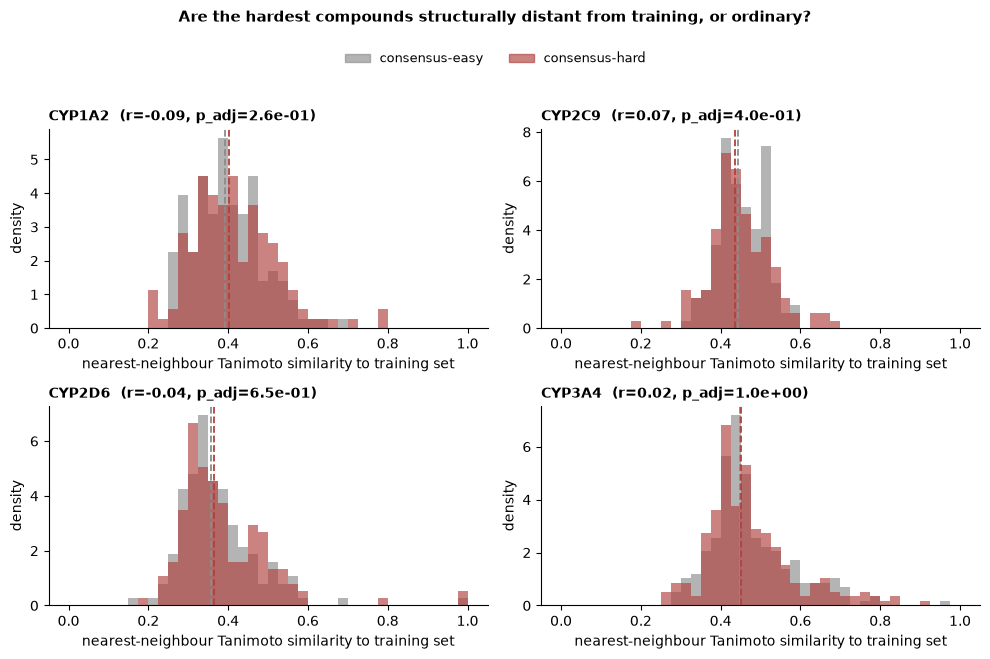

wrote /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/25_hard_compound_analysis/figures/hard_vs_easy_nn_similarity.png


In [16]:
# Figure 1 -- hard_vs_easy_nn_similarity.png (answers Part 4 directly)
fig, axes = plt.subplots(2, 2, figsize=(10, 6))
for ax, iso in zip(axes.flat, ISOFORMS):
    t = compound_tables[iso]
    hard = t.loc[t["hard_soft"], "loo_nn_similarity"]
    easy = t.loc[t["easy_soft"], "loo_nn_similarity"]
    bins = np.linspace(0, 1, 41)
    ax.hist(easy, bins=bins, density=True, color=EASY_COLOR, alpha=0.65, label=f"easy (n={len(easy)})")
    ax.hist(hard, bins=bins, density=True, color=HARD_COLOR, alpha=0.65, label=f"hard (n={len(hard)})")
    ax.axvline(easy.median(), color=EASY_COLOR, linestyle="--", linewidth=1.3)
    ax.axvline(hard.median(), color=HARD_COLOR, linestyle="--", linewidth=1.3)
    row = all_tests[(all_tests["isoform"] == iso) & (all_tests["property"] == "loo_nn_similarity")].iloc[0]
    ax.set_title(f"{iso}  (r={row['rank_biserial_r']:.2f}, p_adj={row['p_adj']:.1e})", fontsize=10, fontweight="bold", loc="left")
    ax.set_xlabel("nearest-neighbour Tanimoto similarity to training set")
    ax.set_ylabel("density")
    strip_axes(ax)

handles = [plt.Rectangle((0, 0), 1, 1, color=EASY_COLOR, alpha=0.65), plt.Rectangle((0, 0), 1, 1, color=HARD_COLOR, alpha=0.65)]
fig.legend(handles, ["consensus-easy", "consensus-hard"], loc="upper center", ncol=2, frameon=False, bbox_to_anchor=(0.5, 1.04), fontsize=9)
fig.suptitle("Are the hardest compounds structurally distant from training, or ordinary?", fontsize=11, fontweight="bold", y=1.09)
plt.tight_layout()
path1 = FIG_OUT / "hard_vs_easy_nn_similarity.png"
fig.savefig(path1, dpi=150, bbox_inches="tight")
plt.show()
print(f"wrote {path1}")


**Figure 1. Nearest-neighbour Tanimoto similarity to the training set, consensus-hard
vs. consensus-easy compounds, per isoform.** Dashed lines mark each group's median.
**Reading — a clean, uniform result across all four isoforms**: the two
distributions overlap almost completely everywhere. Hard-set median similarity
(0.40 / 0.44 / 0.36 / 0.45 for CYP1A2/CYP2C9/CYP2D6/CYP3A4) is statistically
indistinguishable from the easy-set median (0.39 / 0.44 / 0.36 / 0.45) — rank-biserial
r is 0.02-0.09 in magnitude on every isoform, none surviving BH correction. **The
compounds this project's pool fails on are not structurally distant from training on
any isoform** — they are exactly as well-supported by nearest-neighbour structure as
the compounds every model gets right.


properties carried into Figure 2 (material on at least one isoform): ['interval_width', 'y_true', 'MolLogP', 'FractionCSP3', 'net_charge_ph74', 'TPSA', 'HeavyAtomCount']


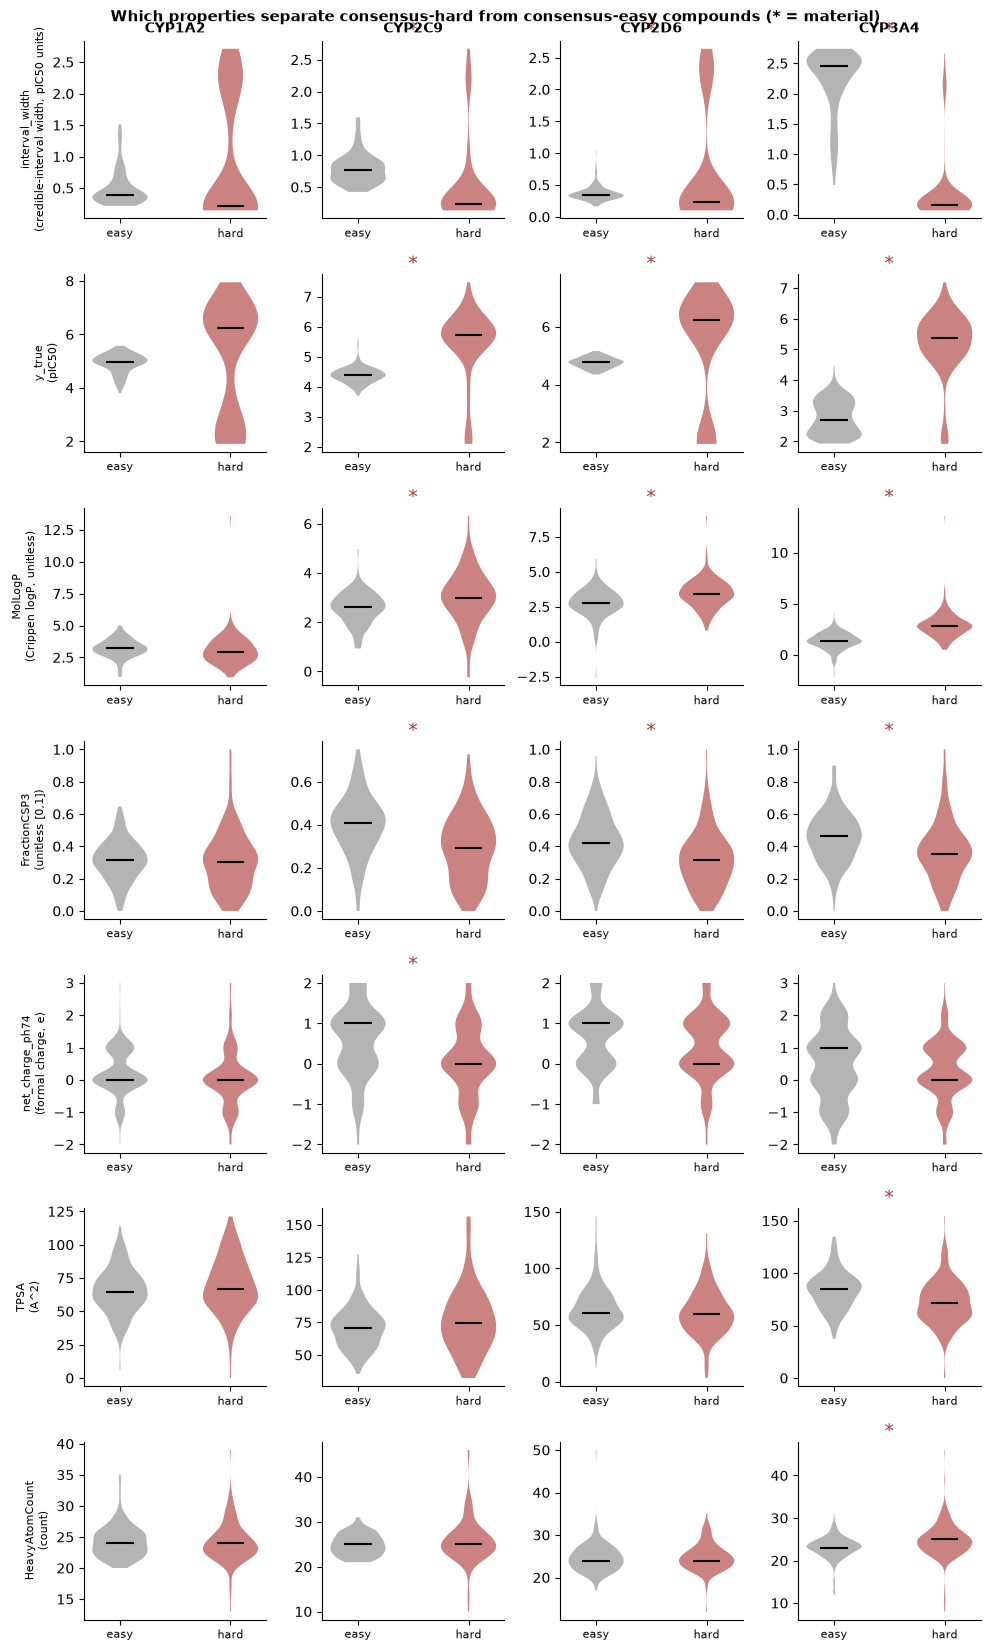

wrote /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/25_hard_compound_analysis/figures/hard_compound_properties.png


In [17]:
# Figure 2 -- hard_compound_properties.png (only the properties that actually separated the groups)
material_props = all_tests.loc[(all_tests["test_kind"] == "continuous") & all_tests["worth_acting_on"], "property"].unique().tolist()
print(f"properties carried into Figure 2 (material on at least one isoform): {material_props}")

if len(material_props) == 0:
    print("No continuous property cleared the material bar on any isoform -- Figure 2 falls back to showing "
          "pIC50 alone (the property most directly relevant to Part 4's potency-extreme question), labelled "
          "as non-material in its own title so the figure is not mistaken for a positive result.")
    material_props = ["y_true"]

n_props = len(material_props)
fig, axes = plt.subplots(n_props, 4, figsize=(10, max(6, 2.4 * n_props)), squeeze=False)
for row_idx, prop in enumerate(material_props):
    unit = CONTINUOUS_PROPERTIES.get(prop, "")
    for col_idx, iso in enumerate(ISOFORMS):
        ax = axes[row_idx, col_idx]
        t = compound_tables[iso]
        hard = t.loc[t["hard_soft"], prop]
        easy = t.loc[t["easy_soft"], prop]
        parts = ax.violinplot([easy.to_numpy(), hard.to_numpy()], showmedians=True, showextrema=False)
        for body, color in zip(parts["bodies"], [EASY_COLOR, HARD_COLOR]):
            body.set_facecolor(color)
            body.set_alpha(0.65)
        parts["cmedians"].set_color("black")
        ax.set_xticks([1, 2])
        ax.set_xticklabels(["easy", "hard"], fontsize=8)
        row = all_tests[(all_tests["isoform"] == iso) & (all_tests["property"] == prop)]
        marker = "*" if (len(row) and row.iloc[0]["worth_acting_on"]) else ""
        if row_idx == 0:
            ax.set_title(iso, fontsize=10, fontweight="bold")
        if col_idx == 0:
            ax.set_ylabel(f"{prop}\n({unit})" if unit else prop, fontsize=8)
        if len(row):
            ax.text(0.5, 1.0, marker, transform=ax.transAxes, ha="center", va="bottom", fontsize=14, color=HARD_COLOR)
        strip_axes(ax)

fig.suptitle("Which properties separate consensus-hard from consensus-easy compounds (* = material)", fontsize=11, fontweight="bold")
plt.tight_layout()
path2 = FIG_OUT / "hard_compound_properties.png"
fig.savefig(path2, dpi=150, bbox_inches="tight")
plt.show()
print(f"wrote {path2}")


**Figure 2. Properties that materially separate consensus-hard from consensus-easy
compounds (asterisk marks BH-significant AND |rank-biserial r| >= 0.3).** CYP1A2 has
no starred panel — nothing tested characterises its hard set by a material margin;
its difficulty is genuinely diffuse on this evidence. On CYP2C9/CYP2D6/CYP3A4, the
same coherent picture recurs: hard compounds sit at **higher measured pIC50** (more
potent), inside **narrower credible intervals** (mechanically harder to satisfy under
the soft-threshold scoring rule that defines "hard" here), are **more lipophilic**
(higher Crippen logP) and **more rigid** (lower FractionCSP3) than easy compounds.
CYP3A4 additionally shows lower TPSA, higher heavy-atom count, and a small but
BH-significant enrichment of acyclic (ring-free, empty Bemis-Murcko scaffold)
compounds in the hard set (4 of 6 such compounds are hard, odds ratio 18.3, n
small). **None of this is structural novelty** — it is potency, assay-interval
geometry, and a lipophilic/rigid physicochemical profile, all properties of
compounds the model has already seen plenty of.


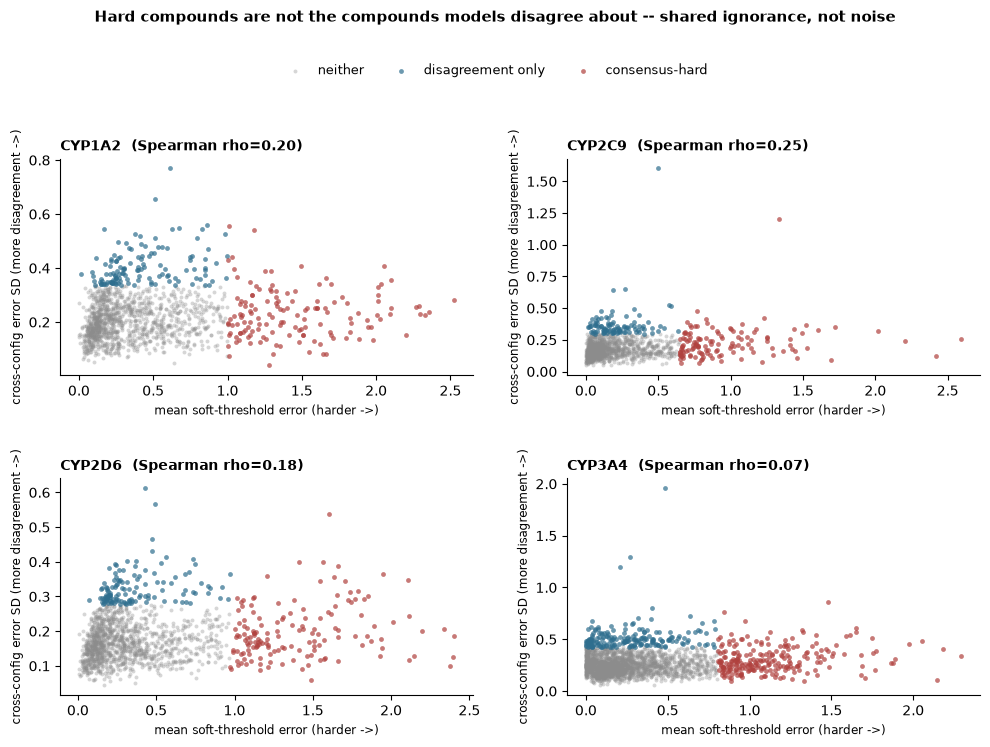

wrote /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/25_hard_compound_analysis/figures/error_correlation_vs_difficulty.png


In [18]:
# Figure 3 -- error_correlation_vs_difficulty.png (the shared-ignorance visual statement)
from scipy.stats import spearmanr

fig, axes = plt.subplots(2, 2, figsize=(10, 7))
for ax, iso in zip(axes.flat, ISOFORMS):
    t = compound_tables[iso]
    x = t["mean_soft_threshold_error"]
    y = t["across_config_sd_signed_error"]
    rho, p_rho = spearmanr(x, y)

    ax.scatter(x[~t["hard_soft"] & ~t["disagreement"]], y[~t["hard_soft"] & ~t["disagreement"]],
               s=8, color=EASY_COLOR, alpha=0.35, label="neither", linewidths=0)
    ax.scatter(x[t["disagreement"] & ~t["hard_soft"]], y[t["disagreement"] & ~t["hard_soft"]],
               s=12, color=DISAGREEMENT_COLOR, alpha=0.7, label="disagreement only", linewidths=0)
    ax.scatter(x[t["hard_soft"]], y[t["hard_soft"]],
               s=12, color=HARD_COLOR, alpha=0.7, label="consensus-hard", linewidths=0)

    ax.set_title(f"{iso}  (Spearman rho={rho:.2f})", fontsize=10, fontweight="bold", loc="left")
    ax.set_xlabel("mean soft-threshold error (harder ->)", fontsize=8.5)
    ax.set_ylabel("cross-config error SD (more disagreement ->)", fontsize=8.5)
    strip_axes(ax)

handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, frameon=False, bbox_to_anchor=(0.5, 1.0), fontsize=9)
fig.suptitle("Hard compounds are not the compounds models disagree about -- shared ignorance, not noise",
             fontsize=11, fontweight="bold", y=1.06)
fig.tight_layout(rect=[0, 0, 1, 0.94], h_pad=3.0, w_pad=2.5)
path3 = FIG_OUT / "error_correlation_vs_difficulty.png"
fig.savefig(path3, dpi=150, bbox_inches="tight")
plt.show()
print(f"wrote {path3}")


**Figure 3. Compound difficulty (x, mean soft-threshold error) vs. cross-model
disagreement (y, SD of signed error across the 11 configs), per isoform.**
Consensus-hard compounds (red) sit far to the right but are **not** systematically
higher on the y-axis than the grey "neither" cloud — Spearman rho between the two
quantities is weak on every isoform (0.20 / 0.25 / 0.18 / 0.07 for
CYP1A2/CYP2C9/CYP2D6/CYP3A4), and the overlap between the consensus-hard and
disagreement sets is small (16/142, 30/129, 25/150, 45/234 compounds respectively —
11-19%). **This is the direct visual counterpart to notebook 24's error-correlation
finding**: the compounds that are hardest are, for the most part, a different
population from the compounds the eleven models disagree about most. Being wrong and
being disputed are largely independent here — consistent with shared ignorance
(every model converging on the same wrong answer) rather than idiosyncratic
per-model noise.


## Part 4 — The question this task exists to answer

**Are the consensus-hard compounds structurally distant from training (a retrieved
corpus could plausibly help), or structurally ordinary (a corpus would be aimed at
the wrong problem)?** Answered per isoform below, from the NN-similarity comparison
in Part 2/Figure 1 — not averaged across isoforms, since notebooks 22 and 23 both
already showed these four isoforms behave differently from each other.

**What this does and does not license, stated explicitly**: this notebook establishes
only whether the failures are of a *kind* a structural neighbour corpus could
address (i.e. whether hard compounds sit in structurally under-sampled territory). It
does **not** establish that such a corpus would actually improve predictions if
built — that would require building it and testing it, which is explicitly out of
scope here.


In [19]:
print("=" * 78)
print("PART 4 VERDICT -- per isoform, not averaged")
print("=" * 78)

for iso in ISOFORMS:
    row = all_tests[(all_tests["isoform"] == iso) & (all_tests["property"] == "loo_nn_similarity")].iloc[0]
    t = compound_tables[iso]
    hard_median_sim = t.loc[t["hard_soft"], "loo_nn_similarity"].median()
    easy_median_sim = t.loc[t["easy_soft"], "loo_nn_similarity"].median()
    material_others = all_tests[(all_tests["isoform"] == iso) & (all_tests["test_kind"] == "continuous")
                                 & (all_tests["property"] != "loo_nn_similarity") & all_tests["worth_acting_on"]]

    print(f"\n{iso}:")
    print(f"  hard-set median NN similarity to training: {hard_median_sim:.3f}")
    print(f"  easy-set median NN similarity to training: {easy_median_sim:.3f}")
    print(f"  NN-similarity separation: rank-biserial r={row['rank_biserial_r']:.3f}, "
          f"BH-adjusted p={row['p_adj']:.2e}, material={row['worth_acting_on']}")

    if row["worth_acting_on"] and hard_median_sim < easy_median_sim:
        print("  VERDICT: hard compounds ARE structurally more distant from training on this evidence -- "
              "a corpus of structures resembling them could plausibly help, since the encoder has "
              "genuinely seen less of that chemistry.")
    elif row["worth_acting_on"] and hard_median_sim >= easy_median_sim:
        print("  VERDICT: hard compounds are, if anything, structurally CLOSER to training than easy "
              "compounds are -- the opposite of the 'structurally distant' premise. A retrieved "
              "structural-neighbour corpus is not supported by this evidence for this isoform.")
    else:
        print("  VERDICT: NN similarity does NOT separate hard from easy by a margin worth acting on -- "
              "hard compounds are structurally ORDINARY relative to training, not distant. A retrieved "
              "structural corpus targeting 'unseen chemistry' is aimed at the wrong problem for this "
              "isoform on this evidence.")

    if len(material_others) > 0:
        print(f"  Other material properties for this isoform: {material_others['property'].tolist()} "
              "-- these, not structural novelty, are the more likely explanation for this isoform's hard set.")
    else:
        print("  No other property (potency, interval width, physicochemistry, scaffold) separates hard "
              "from easy by a material margin either -- consistent with a genuinely diffuse, "
              "hard-to-characterise difficulty for this isoform's hard set.")


PART 4 VERDICT -- per isoform, not averaged

CYP1A2:
  hard-set median NN similarity to training: 0.401
  easy-set median NN similarity to training: 0.391
  NN-similarity separation: rank-biserial r=-0.094, BH-adjusted p=2.56e-01, material=False
  VERDICT: NN similarity does NOT separate hard from easy by a margin worth acting on -- hard compounds are structurally ORDINARY relative to training, not distant. A retrieved structural corpus targeting 'unseen chemistry' is aimed at the wrong problem for this isoform on this evidence.
  No other property (potency, interval width, physicochemistry, scaffold) separates hard from easy by a material margin either -- consistent with a genuinely diffuse, hard-to-characterise difficulty for this isoform's hard set.

CYP2C9:
  hard-set median NN similarity to training: 0.437
  easy-set median NN similarity to training: 0.444
  NN-similarity separation: rank-biserial r=0.068, BH-adjusted p=3.97e-01, material=False
  VERDICT: NN similarity does NOT se

In [20]:
print("=" * 78)
print("Cross-isoform transfer summary (Part 3), read alongside the verdict above")
print("=" * 78)
n_sig_pairs = int(transfer_table["significant"].sum())
print(f"{n_sig_pairs} of {len(transfer_table)} isoform pairs show a BH-significant hard/hard association.")
if n_sig_pairs > 0:
    print(transfer_table[transfer_table['significant']][['isoform_a', 'isoform_b', 'phi', 'p_adj']].round(4).to_string(index=False))
    print("Where significant, this points toward compound-intrinsic difficulty for the compounds shared "
          "between that pair -- exactly the kind of difficulty a structural corpus is positioned to address, "
          "independent of which isoform is being predicted.")
if n_sig_pairs < len(transfer_table):
    print("Where NOT significant, hardness does not transfer between those isoforms for their shared "
          "compounds -- consistent with an isoform-specific mechanism (assay quirk, target-specific SAR) "
          "that a structural corpus, which knows nothing about isoform identity, could not address.")


Cross-isoform transfer summary (Part 3), read alongside the verdict above
3 of 6 isoform pairs show a BH-significant hard/hard association.
isoform_a isoform_b    phi  p_adj
   CYP1A2    CYP2C9 0.1700 0.0184
   CYP1A2    CYP3A4 0.1315 0.0391
   CYP2C9    CYP3A4 0.2628 0.0000
Where significant, this points toward compound-intrinsic difficulty for the compounds shared between that pair -- exactly the kind of difficulty a structural corpus is positioned to address, independent of which isoform is being predicted.
Where NOT significant, hardness does not transfer between those isoforms for their shared compounds -- consistent with an isoform-specific mechanism (assay quirk, target-specific SAR) that a structural corpus, which knows nothing about isoform identity, could not address.


### What this notebook does NOT do

- No model was trained, retrained, or loaded — no Chemprop, no torch import anywhere
  above.
- No external corpus was retrieved, downloaded, or constructed.
- No submission was built, validated, or sent.
- No model change is recommended. The per-isoform verdicts above answer only
  whether the failure population is of a kind a retrieved structural corpus could
  plausibly address — not whether building one would work, and not what to do next.
  That decision is left entirely to the user.
